In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import src
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc("text", usetex=True)
mpl.rc("font", family="serif")

In [2]:
enoe = pd.read_parquet("outputs/enoe_harmonized.parquet")
od = pd.read_parquet("outputs/od_sector_imputed.parquet")
print(f"ENOE workers: {len(enoe):,}")
print(f"OD workers: {len(od):,}")

ENOE workers: 6,793
OD workers: 26,913


## Informality probability model

The ENOE survey observes whether each worker has a formal or informal job, whereas the OD survey does not contain this label. The objective of this stage is therefore to learn the relationship between informality and the harmonized worker characteristics available in both surveys. For an ENOE worker, the model estimates $P(I=1\mid X,S)$, where $I=1$ denotes informal employment, $X$ contains the common sociodemographic and labor attributes, and $S$ denotes economic sector. Sector is observed in ENOE but is uncertain for part of the OD population. Rather than replacing this uncertainty with a single hard sector label, the OD informality probability is obtained by marginalizing over the four possible sectors,

$$P(I_i=1\mid X_i)=\sum_s P(I_i=1\mid X_i,S_i=s)\,P(S_i=s\mid X_i).$$

For workers whose sector was originally observed, $P(S_i=s\mid X_i)$ is one-hot and the expression reduces to the usual conditional prediction. For workers whose sector was imputed, the full sector probability vector is retained. Models are trained using ENOE survey weights and selected primarily through weighted log loss so that predicted probabilities, rather than only hard formal/informal classifications, are the main output.

## Training geography

The informality model is trained using ENOE workers from municipalities represented in both ENOE and OD. This preserves the same geographic comparison used in the previous benchmark analysis.

In [3]:
enoe_informality, geography_summary = src.select_common_informality_population(enoe, od)
print(geography_summary)
print(f"ENOE workers used for informality analysis: {len(enoe_informality):,}")

                municipio   enoe     od  common
0                el_salto   True   True    True
1             guadalajara   True   True    True
2  ixtlahuacan_membrillos   True   True    True
3             juanacatlan  False   True   False
4                    tala   True  False   False
5              tlajomulco   True   True    True
6             tlaquepaque   True   True    True
7                  tonala   True   True    True
8                 zapopan   True   True    True
9             zapotlanejo  False   True   False
ENOE workers used for informality analysis: 5,105


To get an idea of what to expect from the model, we run a simple benchmark with the ENOE data to summarize the proportions and total counts of informal observations. 

In [4]:
informality_benchmark = src.calculate_enoe_informality_benchmark(enoe_informality)
informality_benchmark.round(4)

,sample_workers,weighted_population,weighted_informal_population,unweighted_informality_rate,weighted_informality_rate
0,5105,2427532.0,944728.0,0.3929,0.3892


With this, we see that the weighted informality rate is 38.92%, so we expect the final proportion reported in the OD survey to be close to this value. 

## Predictor missingness

The common ENOE–OD predictors are inspected before training. Education is evaluated explicitly because missing education is considerably more frequent in OD than in ENOE.

In [5]:
predictor_columns = ["genero", "ocupacion", "edad_num", "escolaridad", "municipio", "estado_civil", "parentesco", "tamano_viv_cat"]
predictor_missingness = src.compare_informality_feature_missingness(enoe_informality, od, predictor_columns)
predictor_missingness.round(4)

,variable,enoe_missing_share,od_missing_share
0,genero,0.0000,0.0000
1,ocupacion,0.0000,0.0009
2,edad_num,0.0000,0.0000
3,escolaridad,0.0003,0.1580
4,municipio,0.0000,0.0000
5,estado_civil,0.0000,0.0085
6,parentesco,0.0000,0.0066
7,tamano_viv_cat,0.0000,0.0000


## Common ENOE train-test split

Based on the method used to divide the training and test sets for the sectoral allocation model, a held-out ENOE test sample is reserved before model tuning. Workers belonging to the same household are kept within the same partition.

In [6]:
enoe_informality_train, enoe_informality_test = src.split_enoe_informality_data(enoe_informality, n_splits=5, test_fold=0, random_state=42)
print(f"ENOE workers available for training: {len(enoe_informality_train):,}")
print(f"ENOE workers reserved for testing: {len(enoe_informality_test):,}")

ENOE workers available for training: 4,078
ENOE workers reserved for testing: 1,027


Similar to what we did with the assignment of economic sectors, we created a hybrid model that accounts for the presence or absence of schooling. The only difference in this problem is that the training set is now the ENOE database. 

## Model A: predictors with education

For the first informality model (the specification that includes the education variable), we prepare the ENOE training data in the format required to train the classifiers. Here we obtain the predictor matrix $X$, containing the features defined in `src.INFORMALITY_FEATURES` that the model will use to learn informality; the target variable $y$, given by the binary informal attribute, where 1 represents an informal worker and 0 a formal worker; the weights associated with the ENOE `survey_weight`, which ensure that, during training and evaluation, observations contribute according to the population they represent $^{*}$; the household groups, which are used during cross-validation to ensure that workers belonging to the same household remain within the same fold; and the final dataframe containing the workers that actually participate in the training.

$^{*}$ The survey weights are normalized to a common scale while preserving their relative proportions, so that observations representing a larger share of the population retain greater influence during model fitting and evaluation.

In [7]:
with_education_features = src.INFORMALITY_FEATURES
X_with_education, y_with_education, weights_with_education, groups_with_education, training_with_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=with_education_features)
print(f"Workers used for training: {len(training_with_education):,}")
print(f"Households used for training: {groups_with_education.nunique():,}")

Workers used for training: 4,078
Households used for training: 2,188


Next, we train and evaluate several candidate models for the informality classification problem. Here, we determine which family of algorithms performs best and which hyperparameter configuration provides the best probabilistic performance within each algorithm.

The models we test are as follows:

* **Logistic Regression**:
    * This is the linear baseline. Since informality is a binary classification problem, the model estimates the probability $P(Y=1\mid X)$, where $Y=1$ represents an informal worker and $Y=0$ a formal worker.
    * **Tuned hyperparameters**: `C`: $[0.1, 1.0, 10.0]$
    * **Fixed settings**: `max_iter = 2000`, `random_state = 42`
    * **Configurations**: $3$

* **Random Forest**:
    * An ensemble of decision trees capable of capturing nonlinear relationships and interactions among the predictors.
    * **Tuned hyperparameters**: `max_leaf_nodes`: $[25, 50, 100]$, `max_features`: $[\texttt{"sqrt"}, 0.7]$, `min_samples_leaf`: $[1, 5]$
    * **Fixed settings**: `n_estimators = 300`, `class_weight = None`, `random_state = 42`, and `n_jobs = -1`
    * **Configurations**: $3\times2\times2=12$

* **Gradient Boosting**:
    * An ensemble of decision trees constructed sequentially, where each new stage attempts to improve the errors made by the previous stages.
    * **Tuned hyperparameters**: `learning_rate`: $[0.05, 0.1]$, `max_leaf_nodes`: $[15, 31]$, `l2_regularization`: $[0.0, 1.0]$
    * **Fixed settings**: `max_iter = 500`, `early_stopping = True`, `class_weight = None`, and `random_state = 42`
    * **Configurations**: $2\times2\times2=8$

In total, $23$ hyperparameter configurations are evaluated. Each configuration is assessed using 5-fold StratifiedGroupKFold cross-validation, resulting in $23\times5=115$ train-validation evaluations. Stratification attempts to preserve the proportion of formal and informal workers across folds, while grouping ensures that workers belonging to the same ENOE household remain within the same fold.

As part of the preprocessing, age (`edad_num`) is treated as a numerical variable, while the remaining predictors—including economic sector—are treated as categorical variables. Missing categorical values are represented as `no_especificado`, and categorical predictors are transformed using one-hot encoding. For Logistic Regression, the numerical variable is additionally standardized.

It is important to distinguish survey weighting from class balancing. The ENOE survey_weight is used as a sample weight so that observations contribute according to the population they represent. However, no additional artificial class balancing is applied (`class_weight=None`), meaning that formal or informal workers are not artificially upweighted during training.

Because the objective is to obtain informative probabilities of informality rather than only binary classifications, model selection is primarily based on the weighted binary log loss:

$$\mathcal{L} = -\frac{\sum_i w_i\left[ y_i\log(p_i)+(1-y_i)\log(1-p_i) \right]}{\sum_i w_i},$$


where $w_i$ is the ENOE survey weight associated with observation $i$, $y_i\in{0,1}$ is its observed informality status, and $p_i=P(Y_i=1\mid X_i)$ is the predicted probability of being informal. Lower values of $\mathcal{L}$ indicate better probabilistic predictions.

After evaluating all candidate configurations, the resulting summary reports:

* algorithm
* weighted log loss
* weighted log-loss standard deviation across folds
* weighted Brier score
* weighted balanced accuracy
* weighted accuracy
* weighted F1 score
* weighted ROC AUC
* best hyperparameters

In [8]:
with_education_summary, with_education_models = src.tune_informality_models(X_with_education, y_with_education, weights_with_education, groups_with_education, features=with_education_features, cv_splits=5, random_state=42)
with_education_summary

Tuning LogisticRegression: 3 parameter combinations
Tuning RandomForest: 12 parameter combinations
Tuning GradientBoosting: 8 parameter combinations


,model,weighted_log_loss,weighted_log_loss_std,weighted_brier_score,weighted_balanced_accuracy,weighted_accuracy,weighted_f1,weighted_roc_auc,best_params
0,RandomForest,0.506499,0.032967,0.166189,0.740989,0.765596,0.679054,0.818319,"{'classifier__max_features': 0.7, 'classifier_..."
1,GradientBoosting,0.508257,0.033497,0.167515,0.736722,0.761920,0.673221,0.815493,"{'classifier__l2_regularization': 0.0, 'classi..."
2,LogisticRegression,0.541052,0.026052,0.181597,0.697878,0.726717,0.614706,0.785214,{'classifier__C': 1.0}


In [9]:
with_education_best_name, with_education_best_model = src.get_best_informality_model(with_education_summary, with_education_models)
print(f"Best model with education: {with_education_best_name}")
print(with_education_summary.loc[with_education_summary["model"] == with_education_best_name, "best_params"].iloc[0])

Best model with education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 5}


The **Random Forest** provides the best probabilistic performance, achieving the lowest weighted log loss ($0.5065$), followed closely by Histogram Gradient Boosting ($0.5083$). It also obtains the highest weighted balanced accuracy ($0.7410$), weighted accuracy ($0.7656$), weighted F1 ($0.6791$), and weighted ROC AUC ($0.8183$). Therefore, the Random Forest is selected as the best Model A specification, with `max_features = 0.7`, `max_leaf_nodes = 50`, and `min_samples_leaf = 5`.

Now, we take the best Model A specification (the Random Forest with the optimal hyperparameter settings) and evaluate it on the held-out ENOE test set. These workers were not used during model tuning or hyperparameter selection, so this stage provides an independent assessment of the model's out-of-sample performance.

In [10]:
with_education_metrics, with_education_confusion, with_education_calibration = src.evaluate_informality_model(with_education_best_model, enoe_informality_test, features=with_education_features)
with_education_metrics.round(4)

,accuracy,balanced_accuracy,f1,weighted_accuracy,weighted_balanced_accuracy,weighted_f1,weighted_roc_auc,weighted_log_loss,weighted_brier_score,observed_informality_rate,predicted_informality_rate,calibration_gap_pp
0,0.7556,0.7269,0.6499,0.7572,0.7224,0.637,0.8019,0.5116,0.1691,0.3523,0.387,3.465


The selected Random Forest achieves a weighted accuracy of approximately (75.7%) and a weighted balanced accuracy of (72.2%). The latter indicates that the model maintains reasonably good performance across both formal and informal workers despite differences in their prevalence. The weighted F1 score of ($0.637$) shows moderate performance specifically for identifying the positive class, corresponding to informal employment.

The weighted ROC AUC of ($0.8019$) indicates good discriminatory capacity: the model is generally able to assign higher informality probabilities to informal workers than to formal workers. The weighted log loss is ($0.5116$), close to the cross-validation result of ($0.5065$), indicating stable out-of-sample probabilistic performance and no substantial deterioration on the held-out data. The weighted Brier score of (0.1691) additionally measures the squared error of the predicted probabilities, with lower values indicating better probabilistic predictions.

At the population level, the observed weighted informality rate in the test set is (35.23%), whereas the average predicted probability implies an informality rate of (38.70%). Therefore, the model overestimates the aggregate informality rate by approximately ($3.47$) percentage points. Although the model demonstrates good discrimination, this difference indicates that probability calibration must also be considered when interpreting its predictions.

In [11]:
with_education_confusion.round(2)

,formal,informal
formal,263885.0,50172.0
informal,67558.0,103286.0


The weighted confusion matrix shows that the model identifies formal workers more effectively than informal workers. Approximately 263,885 population-equivalent formal workers are correctly classified as formal, while 50,172 are incorrectly classified as informal. Among informal workers, approximately 103,286 are correctly identified, while 67,558 are incorrectly classified as formal.

This corresponds to an informal-worker recall of approximately (60.5%), meaning that the model identifies around six out of every ten informal workers under a hard (0.5) classification threshold. In contrast, the specificity for formal workers is approximately (84.0%). This asymmetry explains why the weighted balanced accuracy is lower than the overall weighted accuracy: the model performs better for the formal class than for the informal class.

It is important to note that the final application does not rely exclusively on these hard classifications. The primary output is the predicted probability of informality, which retains substantially more information than converting each worker directly into a formal or informal label.

In [12]:
with_education_calibration.round(4)

,bin,sample_workers,weighted_population,weighted_informal,weighted_probability,observed_rate,predicted_probability
0,"(-0.001, 0.1]",56,26082.0,1238.0,2451.4536,0.0475,0.0940
1,"(0.1, 0.2]",276,138458.0,15716.0,17531.5122,0.1135,0.1266
2,"(0.2, 0.3]",152,76214.0,20317.0,19662.5183,0.2666,0.2580
3,"(0.3, 0.4]",137,61270.0,20100.0,21208.7289,0.3281,0.3462
4,"(0.4, 0.5]",65,29419.0,10187.0,13128.2355,0.3463,0.4463
5,"(0.5, 0.6]",66,30468.0,13880.0,16738.8715,0.4556,0.5494
6,"(0.6, 0.7]",71,30535.0,18489.0,19854.2895,0.6055,0.6502
7,"(0.7, 0.8]",60,24981.0,16694.0,18809.4258,0.6683,0.7529
8,"(0.8, 0.9]",123,57405.0,44154.0,48816.3928,0.7692,0.8504
9,"(0.9, 1.0]",21,10069.0,10069.0,9444.2490,1.0000,0.9380


Finally, we evaluate the calibration of the predicted informality probabilities by grouping workers according to their predicted probability and comparing the average predicted probability with the observed weighted informality rate within each group.

A perfectly calibrated model would satisfy

$$P(Y=1\mid \hat{p}=p)\approx p,$$

meaning that, among workers assigned an informality probability of approximately (60%), roughly (60%) should actually be informal.

The results show that the model generally preserves the expected monotonic relationship: groups receiving higher predicted probabilities exhibit higher observed informality rates. Predictions are particularly close to the observed rates in several low-to-intermediate probability intervals. However, the model tends to overestimate informality in a number of the middle and upper probability ranges. For example, workers with an average predicted probability of (44.6%) exhibit an observed informality rate of approximately (34.6%), while those with an average predicted probability of (75.3%) exhibit an observed rate of approximately (66.8%).

This tendency is consistent with the aggregate calibration gap observed previously, where the model predicts an overall informality rate approximately (3.47) percentage points above the observed value. Therefore, the model exhibits good discriminatory performance, but its probabilities show some degree of overestimation and should be interpreted as informative probabilistic scores rather than perfectly calibrated frequencies.

## Model B: predictors without education

We now construct a second informality model that excludes the education attribute from the predictor set. 

The preparation procedure is otherwise identical to that used for Model A. We obtain the predictor matrix $X$, now using the variables defined in `src.INFORMALITY_ROBUST_FEATURES`; the binary target variable $y$, where 1 represents informal employment and 0 formal employment; the normalized ENOE survey weights; the household groups used during grouped cross-validation; and the final dataframe containing the workers that participate in training.

By removing education from the predictor set, this model serves as a robust fallback specification for OD workers whose educational information is unavailable.

In [13]:
without_education_features = src.INFORMALITY_ROBUST_FEATURES
X_without_education, y_without_education, weights_without_education, groups_without_education, training_without_education = src.prepare_enoe_informality_training_data(enoe_informality_train, features=without_education_features)
print(f"Workers used for training: {len(training_without_education):,}")
print(f"Households used for training: {groups_without_education.nunique():,}")

Workers used for training: 4,078
Households used for training: 2,188


As for the Machine Learning models, we use the same three candidate algorithms considered for Model A, with the same hyperparameter search spaces, fixed settings, grouped cross-validation procedure, survey weighting strategy, and primary model-selection metric. The only difference is that education is excluded from the predictor set.

In [15]:
without_education_summary, without_education_models = src.tune_informality_models(X_without_education, y_without_education, weights_without_education, groups_without_education, features=without_education_features, cv_splits=5, random_state=42)
without_education_summary

Tuning LogisticRegression: 3 parameter combinations
Tuning RandomForest: 12 parameter combinations
Tuning GradientBoosting: 8 parameter combinations


,model,weighted_log_loss,weighted_log_loss_std,weighted_brier_score,weighted_balanced_accuracy,weighted_accuracy,weighted_f1,weighted_roc_auc,best_params
0,RandomForest,0.544722,0.041484,0.182679,0.701007,0.735668,0.612251,0.775926,"{'classifier__max_features': 0.7, 'classifier_..."
1,GradientBoosting,0.548662,0.040626,0.183786,0.697571,0.731602,0.609344,0.772213,"{'classifier__l2_regularization': 1.0, 'classi..."
2,LogisticRegression,0.589692,0.036941,0.201519,0.663852,0.707673,0.546664,0.722685,{'classifier__C': 10.0}


In [16]:
without_education_best_name, without_education_best_model = src.get_best_informality_model(without_education_summary, without_education_models)
print(f"Best model without education: {without_education_best_name}")
print(without_education_summary.loc[without_education_summary["model"] == without_education_best_name, "best_params"].iloc[0])

Best model without education: RandomForest
{'classifier__max_features': 0.7, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 5}


As in Model A, the Random Forest provides the best overall probabilistic performance. It achieves the lowest weighted log loss ($0.5447$), the lowest weighted Brier score ($0.1827$), and the highest weighted balanced accuracy ($0.7010$), weighted accuracy ($0.7357$), weighted F1 score ($0.6123$), and weighted ROC AUC ($0.7759$). Therefore, the Random Forest is again selected as the best classifier, with `max_features = 0.7`, `max_leaf_nodes = 50`, and `min_samples_leaf = 5`.

Compared with the model that includes education, predictive performance decreases moderately when education is removed. The weighted log loss increases from $0.5065$ to $0.5447$, while the weighted ROC AUC decreases from $0.8183$ to $0.7759$. Weighted accuracy also decreases from approximately 76.6\% to 73.6\%. These results indicate that education contains useful information for predicting informality, but the model without education still retains substantial predictive capacity

Now, just as for Model A, we take the best Model B specification, and evaluate it on the same held-out ENOE test set.

In [17]:
without_education_metrics, without_education_confusion, without_education_calibration = src.evaluate_informality_model(without_education_best_model, enoe_informality_test, features=without_education_features)
without_education_metrics.round(4)

,accuracy,balanced_accuracy,f1,weighted_accuracy,weighted_balanced_accuracy,weighted_f1,weighted_roc_auc,weighted_log_loss,weighted_brier_score,observed_informality_rate,predicted_informality_rate,calibration_gap_pp
0,0.7429,0.7006,0.6071,0.7461,0.6986,0.5988,0.7711,0.5325,0.1773,0.3523,0.3931,4.0814


The model without education shows a moderate reduction in predictive performance relative to Model A. Weighted accuracy decreases from 75.7\% to 74.6\%, while weighted balanced accuracy decreases from 72.2\% to 69.9\%. Similarly, the weighted F1 score decreases from 0.6370 to 0.5988, and the weighted ROC AUC decreases from 0.8019 to 0.7711. Probabilistic performance also deteriorates slightly, with weighted log loss increasing from 0.5116 to 0.5325 and the weighted Brier score from 0.1691 to 0.1773. These results confirm that education provides useful information for predicting informality, although the model without education retains substantial predictive capacity and remains suitable as a fallback specification for OD workers whose educational information is unavailable.

At the population level, the observed weighted informality rate in the test set is 35.23\%, whereas the average predicted probability corresponds to an informality rate of 39.31\%. This produces a calibration gap of approximately 4.08 percentage points, slightly larger than the 3.47-percentage-point gap observed for Model A. Therefore, removing education not only reduces discrimination moderately but also produces a somewhat larger aggregate overestimation of informality.

In [18]:
without_education_confusion.round(2)

,formal,informal
formal,269949.0,44108.0
informal,78994.0,91850.0


The weighted confusion matrix shows that Model B continues to identify formal workers more effectively than informal workers. Approximately 269,949 population-equivalent formal workers are correctly classified as formal, while 44,108 are incorrectly classified as informal. Among informal workers, approximately 91,850 are correctly identified, whereas 78,994 are incorrectly classified as formal.

Under the 0.5 hard-classification threshold, the model therefore identifies approximately 53.8\% of informal workers, compared with approximately 60.5\% for Model A. At the same time, the proportion of formal workers correctly identified increases to approximately 86.0\%, compared with approximately 84.0\% for Model A. In other words, removing education makes the classifier more conservative in assigning the informal class: it generates fewer false positives among formal workers, but at the cost of missing a larger proportion of truly informal workers. This trade-off contributes to the reduction in weighted balanced accuracy and weighted F1.

In [19]:
without_education_calibration.round(4)

,bin,sample_workers,weighted_population,weighted_informal,weighted_probability,observed_rate,predicted_probability
0,"(-0.001, 0.1]",27,18687.0,384.0,1605.4637,0.0205,0.0859
1,"(0.1, 0.2]",171,87741.0,11263.0,12861.5334,0.1284,0.1466
2,"(0.2, 0.3]",274,126254.0,30657.0,31196.5538,0.2428,0.2471
3,"(0.3, 0.4]",159,70314.0,15387.0,24121.2796,0.2188,0.3431
4,"(0.4, 0.5]",100,45947.0,21303.0,20258.6617,0.4636,0.4409
5,"(0.5, 0.6]",54,25581.0,11729.0,14006.4845,0.4585,0.5475
6,"(0.6, 0.7]",44,21137.0,12968.0,13706.3280,0.6135,0.6485
7,"(0.7, 0.8]",96,42346.0,27431.0,32169.5070,0.6478,0.7597
8,"(0.8, 0.9]",74,34328.0,28056.0,28578.3139,0.8173,0.8325
9,"(0.9, 1.0]",28,12566.0,11666.0,12130.6482,0.9284,0.9654


Finally, we evaluate the calibration of Model B by comparing the average predicted informality probability with the observed weighted informality rate within probability intervals.

As with Model A, the results preserve the expected general relationship: workers assigned higher predicted probabilities tend to exhibit higher observed informality rates. Several intervals show close agreement between predicted and observed probabilities. For example, in the 0.2–0.3 interval, the average predicted probability is 24.7\%, compared with an observed informality rate of 24.3\%, while in the 0.8–0.9 interval the corresponding values are 83.3\% and 81.7\%.

However, some calibration deviations remain in some intermediate ranges. The most relevant example occurs in the 0.3–0.4 interval, where the model predicts an average informality probability of 34.3\%, while the observed rate is only 21.9\%. The model also tends to overestimate informality in the 0.5–0.8 probability range. These deviations are consistent with the positive aggregate calibration gap of approximately 4.08 percentage points.

Overall, Model B retains a meaningful ordering of informality risk and reasonable probabilistic performance, but its predictions are somewhat less discriminative and slightly less well calibrated than those of Model A. 

## Model comparison

Weighted log loss and Brier score are the primary probability-quality metrics. Classification metrics are retained as secondary diagnostics, while the difference between the observed and predicted weighted informality rates provides a direct calibration check.

In [20]:
model_comparison = pd.concat([with_education_metrics.assign(features="Con escolaridad"), without_education_metrics.assign(features="Sin escolaridad")], ignore_index=True)
model_comparison.round(4)

,accuracy,balanced_accuracy,f1,weighted_accuracy,weighted_balanced_accuracy,weighted_f1,weighted_roc_auc,weighted_log_loss,weighted_brier_score,observed_informality_rate,predicted_informality_rate,calibration_gap_pp,features
0,0.7556,0.7269,0.6499,0.7572,0.7224,0.6370,0.8019,0.5116,0.1691,0.3523,0.3870,3.4650,Con escolaridad
1,0.7429,0.7006,0.6071,0.7461,0.6986,0.5988,0.7711,0.5325,0.1773,0.3523,0.3931,4.0814,Sin escolaridad


Model A consistently outperforms Model B on the held-out ENOE test set. Including education results in lower weighted log loss and Brier score, higher ROC AUC and balanced accuracy, and a smaller aggregate calibration gap. This confirms that education provides useful information for predicting informality.

Nevertheless, the deterioration produced by excluding education remains moderate. Model B retains meaningful discriminatory and probabilistic performance, making it a suitable fallback for OD workers whose educational information is unavailable. Therefore, the final informality estimation follows a hybrid strategy: Model A is used whenever education is available, while Model B is used otherwise.

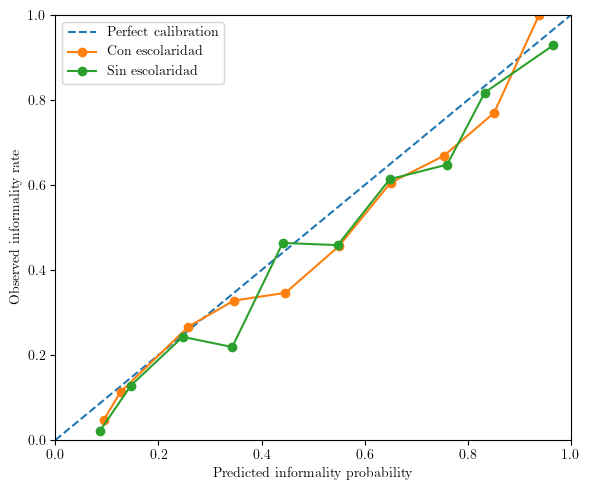

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
ax.plot(with_education_calibration["predicted_probability"], with_education_calibration["observed_rate"], marker="o", label="Con escolaridad")
ax.plot(without_education_calibration["predicted_probability"], without_education_calibration["observed_rate"], marker="o", label="Sin escolaridad")
ax.set_xlabel("Predicted informality probability")
ax.set_ylabel("Observed informality rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Hybrid informality model

The first step in constructing the hybrid informality model is to perform a final refit of the two selected Random Forest specifications using the complete ENOE analytical sample. Since model selection and independent evaluation have already been completed using the training and held-out test subsets, the previously held-out observations can now be reincorporated into the final training data.

For each specification, we create a clean copy of the selected model, preserving its preprocessing pipeline and optimal hyperparameters while discarding the parameters previously learned from the training subset. Each model is then retrained from scratch using all ENOE workers available for the informality modeling stage.

The two final models retain different predictor sets: Model A includes education and will be used for OD workers whose educational information is available, while Model B excludes education and serves as a fallback when this information is unavailable. Sector uncertainty is incorporated later, during prediction, by evaluating informality under each possible economic sector and marginalizing these conditional probabilities using the sector probabilities obtained in the previous notebook.

In [21]:
final_with_education_model, final_with_education_training = src.refit_informality_model(with_education_best_model, enoe_informality, features=with_education_features)
final_without_education_model, final_without_education_training = src.refit_informality_model(without_education_best_model, enoe_informality, features=without_education_features)
print(f"Workers used for final ENOE training: {len(final_with_education_training):,}")

Workers used for final ENOE training: 5,105


Now we apply the final hybrid informality model to the complete OD worker population. For each worker, we first determine whether educational information is available. If it is, Model A is used; otherwise, Model B is applied.

The selected informality model is then evaluated under each of the four possible economic sectors. For workers with an observed sector, the corresponding sector probability is effectively equal to one, while the remaining sector probabilities are zero. For workers whose sector was previously imputed, the four sector probabilities obtained from the sector-imputation model are retained.

The final probability of informality is therefore obtained by marginalizing over the four possible economic sectors:

$$ P(I_i=1\mid X_i) = \sum_s P(I_i=1\mid X_i,S_i=s)\, P(S_i=s\mid X_i). $$

This allows sector uncertainty from the previous modeling stage to propagate directly into the final informality estimate rather than replacing it with a single hard sector assignment.


In [24]:
od_informality = src.predict_od_informality(final_with_education_model, final_without_education_model, od, with_education_features=with_education_features, without_education_features=without_education_features)
informality_model_usage = src.calculate_informality_model_usage(od_informality)
informality_model_usage.round(4)

,informality_model_used,sample_workers,weighted_population,sample_share,weighted_share
0,with_education,21718,1913445,0.807,0.842
1,without_education,5195,358933,0.193,0.158


Model A is used for 21,718 workers, representing approximately 80.7\% of the OD worker sample and 84.2\% of the weighted worker population. Model B is required for the remaining 5,195 workers, corresponding to 19.3\% of the sample and $15.8\% of the weighted population.

The 5,195 workers assigned to Model B coincide with the workers for whom educational information was previously identified as unavailable. This confirms that the hybrid model is operating consistently with the missing-data diagnostics: education is used whenever it is available, while the robust specification is applied only when necessary.

In [25]:
od_informality_summary = src.calculate_od_informality_summary(od_informality)
od_informality_summary.round(4)

,sample_workers,weighted_population,expected_informal_population,expected_formal_population,expected_informality_rate,hard_informality_rate,hard_sector_expected_rate
0,26913,2272378,765129.2491,1.507249e+06,0.3367,0.2135,0.3411


The final probabilistic estimates cover all 26,913 OD workers, representing approximately 2.27 million workers after applying the OD expansion factors. Summing the individual informality probabilities yields an expected informal population of approximately 765,129 workers and an expected formal population of approximately 1.51 million workers.

This corresponds to an estimated weighted informality rate of 33.67\%, obtained from the weighted average of the individual informality probabilities:

$$ \hat r_I = \frac{\sum_i w_iP(I_i=1\mid X_i)} {\sum_i w_i}, $$

and therefore retains the uncertainty contained in both the informality model and, when applicable, the sector-imputation model.

In [26]:
informality_by_sector = src.calculate_informality_by_sector(od_informality)
informality_by_sector.round(4)

,sector,weighted_population,expected_informal_population,expected_formal_population,expected_informality_rate
0,comercio,701940.1247,289543.3518,412396.7728,0.4125
1,gobierno_otro_agricultura,122619.5777,16775.3837,105844.1941,0.1368
2,manufactura_construccion,617885.8211,140428.8358,477456.9853,0.2273
3,servicios_transporte,829932.4765,318381.6778,511550.7987,0.3836


Finally, we decompose the expected informal population by economic sector. Because sector uncertainty is retained, workers with imputed sectors contribute fractionally to each sector according to their predicted sector probabilities. The results show substantial differences in expected informality across sectors. Commerce exhibits the highest estimated informality rate at approximately 41.3\%, followed by services and transport at 38.4\%. Manufacturing and construction show a lower expected rate of approximately 22.7\%, while government, agriculture, and other activities present the lowest estimated informality rate at approximately 13.7\%.

## Comparison of ENOE Results with the Model

In [33]:
import numpy as np
from matplotlib.gridspec import GridSpec

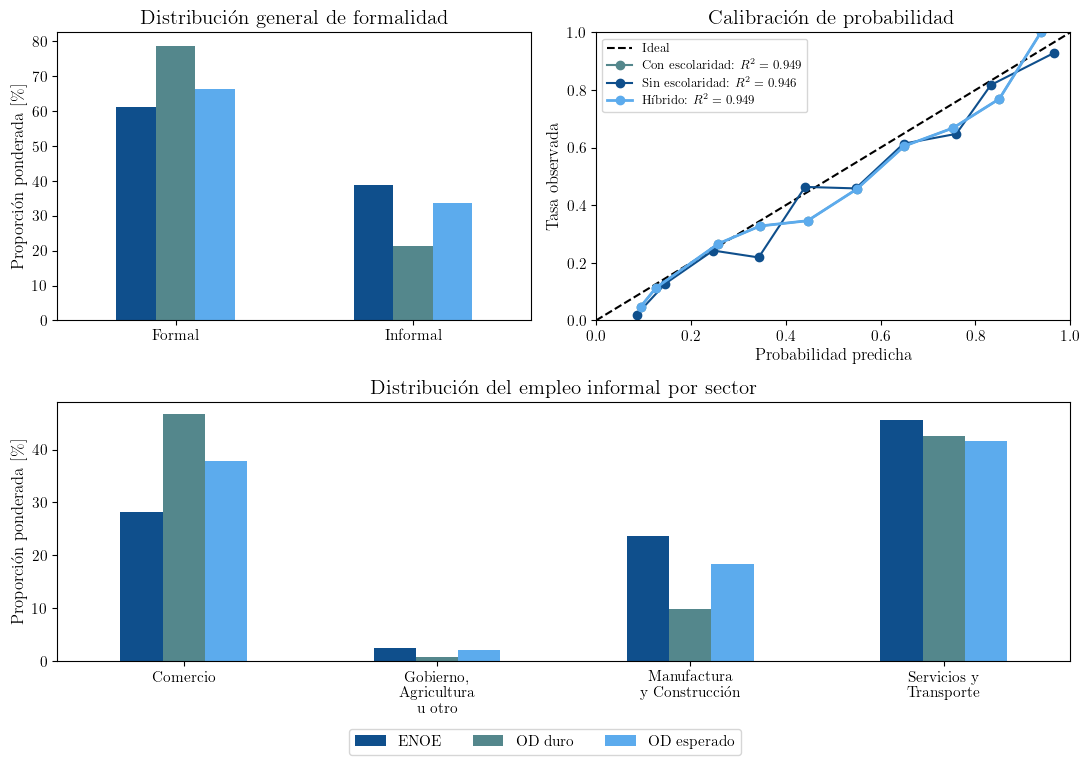

Distribución general formal / informal
           ENOE  OD duro  OD esperado
Formal    61.08    78.65        66.33
Informal  38.92    21.35        33.67

Distribución del empleo informal por sector
                                 ENOE  OD duro  OD esperado
sector                                                     
Comercio                        28.22     46.7        37.84
Gobierno,\nAgricultura\nu otro   2.54     0.79         2.19
Manufactura\ny Construcción     23.73     9.88        18.35
Servicios y\nTransporte         45.51    42.63        41.61

Tasa de informalidad dentro de cada sector
                                 ENOE  OD duro  OD esperado
sector                                                     
Comercio                        47.59    35.91        41.25
Gobierno,\nAgricultura\nu otro  17.76     5.93        13.68
Manufactura\ny Construcción     30.02     7.82        22.73
Servicios y\nTransporte         43.63    21.45        38.36

Calibración del modelo híbrido
      

In [ ]:
sector_labels = {
    "comercio": "Comercio",
    "gobierno_otro_agricultura": "Gobierno,\nAgricultura\nu otro",
    "manufactura_construccion": "Manufactura\ny Construcción",
    "servicios_transporte": "Servicios y\nTransporte"
}

sector_order = list(sector_labels.keys())

known_color = (0.06, 0.31, 0.55)
assigned_color = (0.33, 0.53, 0.55)
final_color = (0.36, 0.67, 0.93)

def calibration_r2(calibration_df):
    calibration_data = calibration_df[["observed_rate", "predicted_probability"]].dropna()
    y_true = calibration_data["observed_rate"].to_numpy()
    y_pred = calibration_data["predicted_probability"].to_numpy()
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return np.nan if ss_tot == 0 else 1 - ss_res / ss_tot

# Distribución general formal / informal
enoe_total_population = enoe_informality["survey_weight"].sum()
enoe_informal_population = (enoe_informality["survey_weight"] * enoe_informality["informal"]).sum()
enoe_formal_population = enoe_total_population - enoe_informal_population

od_total_population = od_informality["expansion_factor"].sum()
od_hard_informal_population = od_informality.loc[od_informality["informal_predicted"] == 1, "expansion_factor"].sum()
od_hard_formal_population = od_total_population - od_hard_informal_population
od_expected_informal_population = (od_informality["expansion_factor"] * od_informality["prob_informal"]).sum()
od_expected_formal_population = od_total_population - od_expected_informal_population

overall_formality_distribution = pd.DataFrame({
    "ENOE": [enoe_formal_population / enoe_total_population, enoe_informal_population / enoe_total_population],
    "OD duro": [od_hard_formal_population / od_total_population, od_hard_informal_population / od_total_population],
    "OD esperado": [od_expected_formal_population / od_total_population, od_expected_informal_population / od_total_population]
}, index=["Formal", "Informal"]) * 100

# Distribución del empleo informal por sector
od_hard_informal = od_informality[od_informality["informal_predicted"] == 1].copy()
od_hard_by_sector = od_hard_informal.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_by_sector = od_hard_by_sector / od_hard_by_sector.sum()

od_expected_by_sector = pd.Series({
    sector: (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
    for sector in sector_order
})
od_expected_by_sector = od_expected_by_sector / od_expected_by_sector.sum()

enoe_informal = enoe_informality[enoe_informality["informal"] == 1].copy()
enoe_by_sector = enoe_informal.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_by_sector = enoe_by_sector / enoe_by_sector.sum()

informal_distribution_by_sector = pd.DataFrame({
    "ENOE": enoe_by_sector * 100,
    "OD duro": od_hard_by_sector * 100,
    "OD esperado": od_expected_by_sector * 100
})

informal_distribution_by_sector.index = informal_distribution_by_sector.index.map(sector_labels)
informal_distribution_by_sector.index.name = "sector"


# Tasa de informalidad dentro de cada sector
od_hard_sector_population = od_informality.groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_informal_population_by_sector = od_informality[od_informality["informal_predicted"] == 1].groupby("sector_final")["expansion_factor"].sum().reindex(sector_order, fill_value=0)
od_hard_within_sector = od_hard_informal_population_by_sector / od_hard_sector_population

od_expected_within_sector = pd.Series({
    sector: (
        (od_informality["expansion_factor"] * od_informality[f"prob_informal_sector_{sector}"]).sum()
        /
        (od_informality["expansion_factor"] * od_informality[f"prob_sector_{sector}"]).sum()
    )
    for sector in sector_order
})

enoe_sector_population = enoe_informality.groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_informal_population_by_sector = enoe_informality[enoe_informality["informal"] == 1].groupby("sector")["survey_weight"].sum().reindex(sector_order, fill_value=0)
enoe_within_sector = enoe_informal_population_by_sector / enoe_sector_population

informality_within_sector = pd.DataFrame({
    "ENOE": enoe_within_sector * 100,
    "OD duro": od_hard_within_sector * 100,
    "OD esperado": od_expected_within_sector * 100
})

informality_within_sector.index = informality_within_sector.index.map(sector_labels)
informality_within_sector.index.name = "sector"

# Calibración del modelo híbrido
education_available = enoe_informality_test["escolaridad"].notna() & (enoe_informality_test["escolaridad"] != "no_especificado")

prob_with_education = with_education_best_model.predict_proba(enoe_informality_test[with_education_features])[:, 1]
prob_without_education = without_education_best_model.predict_proba(enoe_informality_test[without_education_features])[:, 1]

hybrid_probability = np.where(education_available, prob_with_education, prob_without_education)

hybrid_test = enoe_informality_test[["informal", "survey_weight"]].copy()
hybrid_test["predicted_probability"] = hybrid_probability
hybrid_test["bin"] = pd.cut(hybrid_test["predicted_probability"], bins=np.linspace(0, 1, 11), include_lowest=True)

hybrid_test["weighted_informal"] = hybrid_test["survey_weight"] * hybrid_test["informal"]
hybrid_test["weighted_probability"] = hybrid_test["survey_weight"] * hybrid_test["predicted_probability"]

hybrid_calibration = hybrid_test.groupby("bin", observed=False).agg(
    sample_workers=("informal", "size"),
    weighted_population=("survey_weight", "sum"),
    weighted_informal=("weighted_informal", "sum"),
    weighted_probability=("weighted_probability", "sum")
).reset_index()

hybrid_calibration["observed_rate"] = hybrid_calibration["weighted_informal"] / hybrid_calibration["weighted_population"]
hybrid_calibration["predicted_probability"] = hybrid_calibration["weighted_probability"] / hybrid_calibration["weighted_population"]

# R^2 de calibración
r2_with_education = calibration_r2(with_education_calibration)
r2_without_education = calibration_r2(without_education_calibration)
r2_hybrid = calibration_r2(hybrid_calibration)


# 6) Plots
fig = plt.figure(figsize=(11, 8))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 0.9])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Arriba izquierda: Distribución general formal / informal
overall_formality_distribution.plot(kind="bar", ax=ax1, color=[known_color, assigned_color, final_color])

ax1.set_title("Distribución general de formalidad", fontsize=15)
ax1.set_xlabel("")
ax1.set_ylabel("Proporción ponderada [\%]", fontsize=12)
ax1.tick_params(axis="x", rotation=0, labelsize=11)
ax1.tick_params(axis="y", labelsize=11)

handles, labels = ax1.get_legend_handles_labels()
ax1.get_legend().remove()

# Arriba derecha: Calibración
ax2.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1.5, label="Ideal")

ax2.plot(with_education_calibration["predicted_probability"], with_education_calibration["observed_rate"], marker="o", color=assigned_color, label=rf"Con escolaridad: $R^2={r2_with_education:.3f}$")

ax2.plot(without_education_calibration["predicted_probability"], without_education_calibration["observed_rate"], marker="o", color=known_color, label=rf"Sin escolaridad: $R^2={r2_without_education:.3f}$")

ax2.plot(hybrid_calibration["predicted_probability"], hybrid_calibration["observed_rate"], marker="o", color=final_color, linewidth=2, label=rf"Híbrido: $R^2={r2_hybrid:.3f}$")

ax2.set_title("Calibración de probabilidad", fontsize=15)
ax2.set_xlabel("Probabilidad predicha", fontsize=12)
ax2.set_ylabel("Tasa observada", fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", labelsize=11)
ax2.tick_params(axis="y", labelsize=11)
ax2.legend(fontsize=9)

# Abajo: distribución del empleo informal por sector
informal_distribution_by_sector.plot(kind="bar", ax=ax3, color=[known_color, assigned_color, final_color])

ax3.set_title("Distribución del empleo informal por sector", fontsize=15)
ax3.set_xlabel("")
ax3.set_ylabel("Proporción ponderada [\%]", fontsize=12)
ax3.tick_params(axis="x", rotation=0, labelsize=11)
ax3.tick_params(axis="y", labelsize=11)
ax3.get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=11, bbox_to_anchor=(0.5, 0.04), frameon=True)

output_dir = Path("outputs/figures")
output_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(output_dir / "informality_model_enoe_od_comparison.pdf", bbox_inches="tight")
fig.savefig(output_dir / "informality_model_enoe_od_comparison.png", dpi=600, bbox_inches="tight")

plt.show()

# Tablas resumen
print("Distribución general formal / informal")
print(overall_formality_distribution.round(2))

print("\nDistribución del empleo informal por sector")
print(informal_distribution_by_sector.round(2))

print("\nTasa de informalidad dentro de cada sector")
print(informality_within_sector.round(2))

print("\nCalibración del modelo híbrido")
print(hybrid_calibration.round(4))

print(f"\nR² con escolaridad: {r2_with_education:.4f}")
print(f"R² sin escolaridad: {r2_without_education:.4f}")
print(f"R² híbrido: {r2_hybrid:.4f}")

## Export and final validation

In [41]:
od_informality["formalidad_predicha"] = od_informality["informal_predicted"].map({0: "formal", 1: "informal"}).astype("string")

assert len(od_informality) == len(od)
assert od_informality["prob_informal"].notna().all()
assert od_informality["prob_formal"].notna().all()
assert od_informality["informal_predicted"].notna().all()
assert od_informality["prob_informal"].between(0, 1).all()
assert od_informality["prob_formal"].between(0, 1).all()
assert ((od_informality["prob_informal"] + od_informality["prob_formal"] - 1).abs() < 1e-8).all()
assert od_informality["expected_informal_population"].notna().all()
assert od_informality["expected_formal_population"].notna().all()

print("Final informality validation passed.")

Final informality validation passed.


In [42]:
total_population = od_informality["expansion_factor"].sum()
informal_population = od_informality["expected_informal_population"].sum()
formal_population = od_informality["expected_formal_population"].sum()

print(f"Total weighted workers: {total_population:,.0f}")
print(f"Expected informal workers: {informal_population:,.0f}")
print(f"Expected formal workers: {formal_population:,.0f}")
print(f"Population difference: {total_population - informal_population - formal_population:.6f}")

Total weighted workers: 2,272,378
Expected informal workers: 765,129
Expected formal workers: 1,507,249
Population difference: 0.000000


In [43]:
output_directory = Path("outputs")
output_directory.mkdir(exist_ok=True)

output_path = output_directory / "od_informality_imputed.parquet"
od_informality.to_parquet(output_path, index=False)

In [44]:
from joblib import dump

models_directory = Path("outputs/models")
models_directory.mkdir(parents=True, exist_ok=True)

informality_model_bundle = {
    "model_with_education": final_with_education_model,
    "model_without_education": final_without_education_model,
    "features_with_education": with_education_features,
    "features_without_education": without_education_features,
    "sector_classes": src.informality_model.SECTOR_CLASSES
}

model_path = models_directory / "informality_hybrid_model.joblib"
dump(informality_model_bundle, model_path)

print(f"Saved: {model_path}")

Saved: outputs/models/informality_hybrid_model.joblib
